# Devoir : Machine Learning & Text Mining
Les arbres de décision - Application Crédit Scoring

1. Imports

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

2. Load Dataset

In [79]:
data = pd.read_csv("data/CreditScoring.csv")
data.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


3. Analyse du Dataset

In [80]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


In [81]:
data.describe(include='all')

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,5960.000000,5960.000000,5442.000000,5848.000000,5708,5681,5445.000000,5252.000000,5380.000000,5652.000000,5450.000000,5738.000000,4693.000000
unique,NaN,NaN,NaN,NaN,2,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,DebtCon,Other,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,3928,2388,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.199497,18607.969799,73760.817200,101776.048741,NaN,NaN,8.922268,0.254570,0.449442,179.766275,1.186055,21.296096,33.779915
std,0.399656,11207.480417,44457.609458,57385.775334,NaN,NaN,7.573982,0.846047,1.127266,85.810092,1.728675,10.138933,8.601746
min,0.000000,1100.000000,2063.000000,8000.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.524499
25%,0.000000,11100.000000,46276.000000,66075.500000,NaN,NaN,3.000000,0.000000,0.000000,115.116702,0.000000,15.000000,29.140031
50%,0.000000,16300.000000,65019.000000,89235.500000,NaN,NaN,7.000000,0.000000,0.000000,173.466667,1.000000,20.000000,34.818262
75%,0.000000,23300.000000,91488.000000,119824.250000,NaN,NaN,13.000000,0.000000,0.000000,231.562278,2.000000,26.000000,39.003141


Distribution de la variable cible `BAD`

In [82]:
data['BAD'].value_counts()

BAD
0    4771
1    1189
Name: count, dtype: int64

Taux de défaut (BAD=1)

In [83]:
data['BAD'].mean()*100

19.949664429530202

Taux de bon payeur (BAD=0)

In [84]:
(1-data['BAD'].mean())*100

80.0503355704698

Visualisation de la distribution de la cible

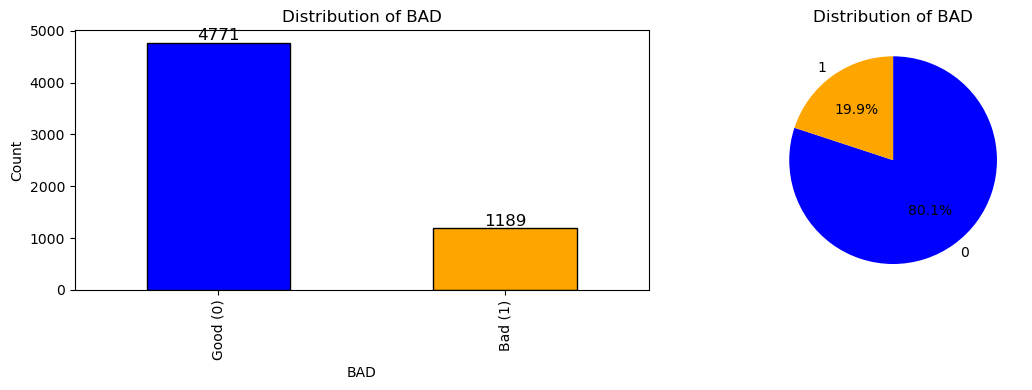

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data['BAD'].value_counts().plot(kind='bar', ax=axes[0], color=['blue', 'orange'], edgecolor='black')
axes[0].set_title('Distribution of BAD')
axes[0].set_xlabel('BAD')
axes[0].set_ylabel('Count')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Good (0)', 'Bad (1)'])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')
data['BAD'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['blue', 'orange'], startangle=90, counterclock=False)
axes[1].set_title('Distribution of BAD')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('figs/target_distribution.png')
plt.show()

## Problèmes dans le dataset

In [86]:
missing = data.isnull().sum()
missing_percent = (missing / len(data)) * 100
print(missing_percent)

BAD         0.000000
LOAN        0.000000
MORTDUE     8.691275
VALUE       1.879195
REASON      4.228188
JOB         4.681208
YOJ         8.640940
DEROG      11.879195
DELINQ      9.731544
CLAGE       5.167785
NINQ        8.557047
CLNO        3.724832
DEBTINC    21.258389
dtype: float64


In [87]:
missing_data = pd.DataFrame({'Missing Count': missing, 'Missing Percentage': missing_percent}).sort_values(by='Missing Count', ascending=False)
missing_data.head()

,Missing Count,Missing Percentage
DEBTINC,1267,21.258389
DEROG,708,11.879195
DELINQ,580,9.731544
MORTDUE,518,8.691275
YOJ,515,8.640940


Heatmap des valeurs manquantes

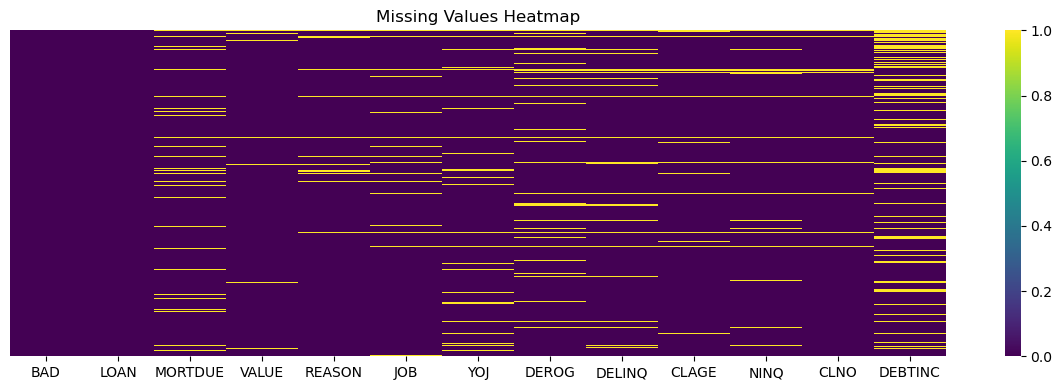

In [88]:
plt.figure(figsize=(12,4))
sns.heatmap(data.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.savefig('figs/missing_values_heatmap.png', dpi=150)
plt.show()

Déséquilibre des classes

In [89]:
vc = data['BAD'].value_counts()
ratio = vc[0]/vc[1]
print(f"  BAD=0 : {vc[0]} ({vc[0]/len(data)*100:.1f}%)")
print(f"  BAD=1 : {vc[1]} ({vc[1]/len(data)*100:.1f}%)")
print(f"  Ratio 0/1 : {ratio:.2f}:1; DÉSÉQUILIBRE SIGNIFICATIF")

  BAD=0 : 4771 (80.1%)
  BAD=1 : 1189 (19.9%)
  Ratio 0/1 : 4.01:1; DÉSÉQUILIBRE SIGNIFICATIF


Valeurs aberrantes

In [90]:
numeric_cols = data.select_dtypes(include=[np.number]).columns.drop('BAD')
outlier_summary = []
for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3-Q1
    outliers = data[(data[col] < Q1- 1.5*IQR) | (data[col] > Q3 + 1.5*IQR)]
    outlier_summary.append({'Feature': col, 'Nb outliers': len(outliers),
                            ' % outliers': round(len(outliers)/len(data)*100, 2)})
    
outliers = pd.DataFrame(outlier_summary)
outliers.head()

,Feature,Nb outliers,% outliers
0,LOAN,256,4.30
1,MORTDUE,234,3.93
2,VALUE,320,5.37
3,YOJ,91,1.53
4,DEROG,725,12.16


Boxplots pour visualiser les outliers

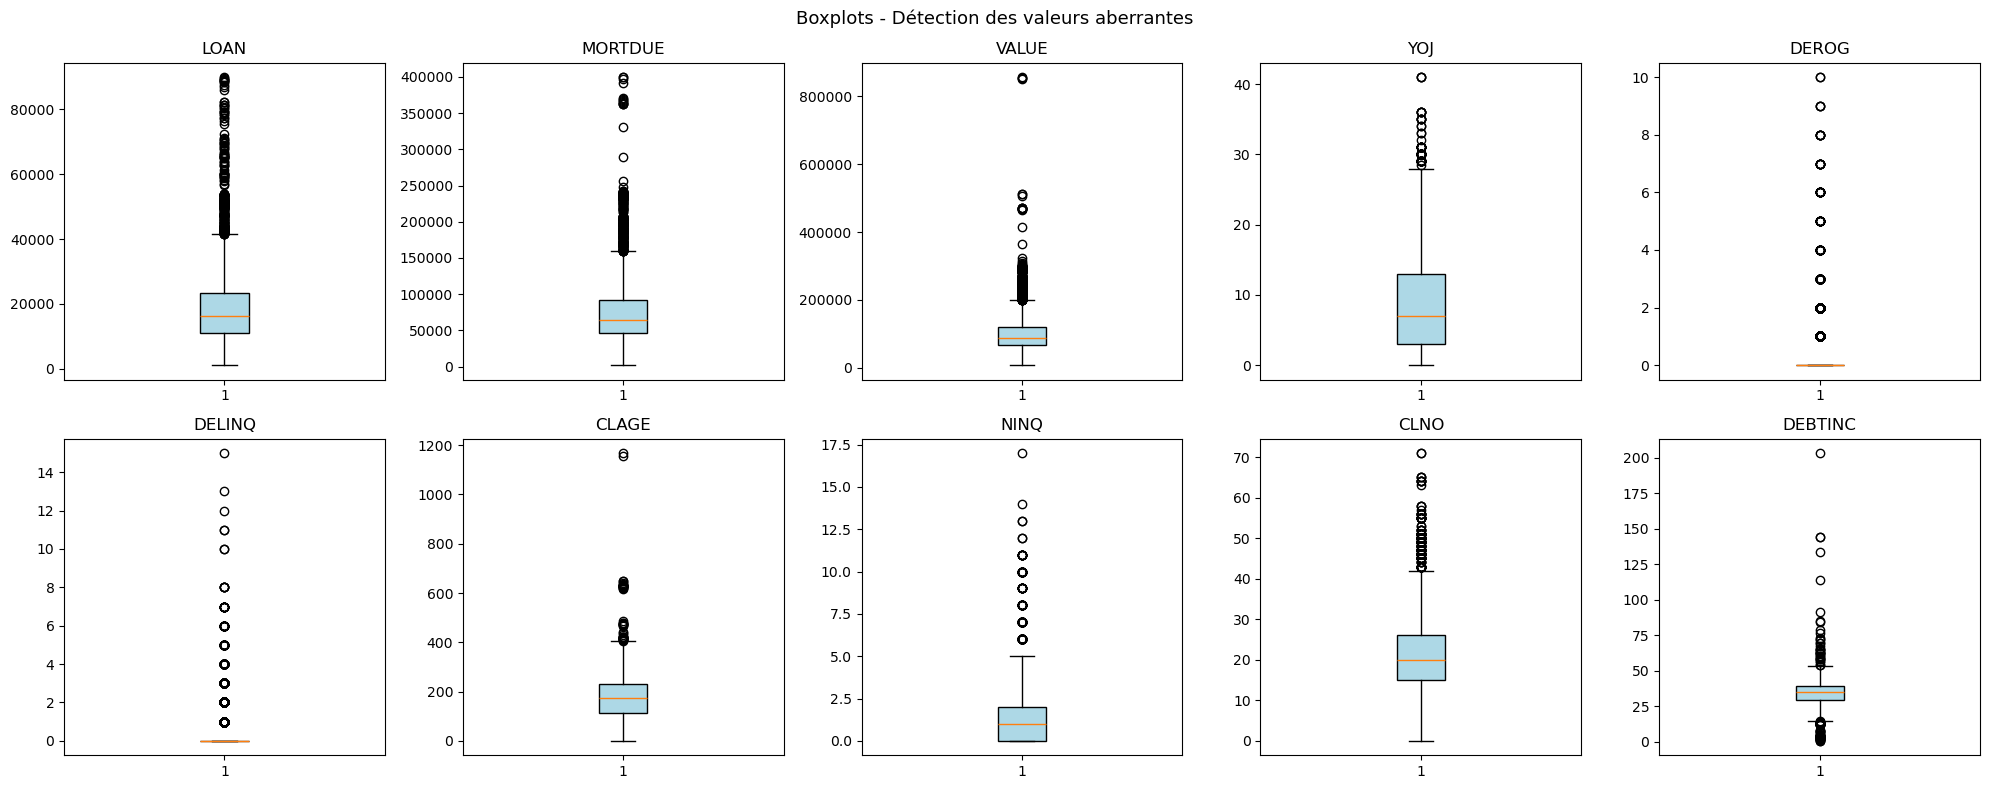

In [91]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(data[col].dropna(), vert=True,
                    patch_artist=True, boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('')
plt.suptitle('Boxplots - Détection des valeurs aberrantes', fontsize=13)
plt.tight_layout()
plt.savefig('figs/q2_outliers.png', dpi=150)
plt.show()

Les doublons

In [92]:
data.duplicated().sum()

0

Gain d'information (Entropy) & Indice de GINI

In [93]:
data_processed = data.copy()
le = LabelEncoder()
for col in ['REASON', 'JOB']:
    data_processed[col] = data_processed[col].fillna('Unknown')
    data_processed[col] = le.fit_transform(data_processed[col].astype(str))

for col in data_processed.columns:
    if data_processed[col].isnull().any():
        if data_processed[col].dtype in ['float64', 'int64']:
            data_processed[col].fillna(data_processed[col].median(), inplace=True)

X = data_processed.drop('BAD', axis=1)
y = data_processed['BAD']

fonctions utilitaires

In [94]:
def entropy(y):
    p1 = y.mean()
    p0 = 1 - p1
    if p1 == 0 or p0 == 0:
        return 0
    return -p1 * np.log2(p1) - p0 * np.log2(p0)

def gini_impurity(y):
    p1 = y.mean()
    p0 = 1 - p1
    return 1 - (p1**2 + p0**2)

def information_gain(X_col, y, bins=10):
    H_parent = entropy(y)
    X_binned = pd.cut(X_col, bins=bins, duplicates='drop')
    H_children = 0
    for val in X_binned.unique():
        if pd.isna(val):
            continue
        mask = X_binned == val
        weight = mask.sum() / len(y)
        H_children += weight * entropy(y[mask])
    return H_parent - H_children

def gini_gain(X_col,y,bins = 10):
    G_parent = gini_impurity(y)
    X_binned = pd.cut(X_col, bins=bins, duplicates='drop')
    G_children = 0
    for val in X_binned.unique():
        if pd.isna(val):
            continue
        mask = X_binned == val
        weight = mask.sum() / len(y)
        G_children += weight * gini_impurity(y[mask])
    return G_parent - G_children

Calcul pour chaque attribut

In [95]:
H_total = entropy(y)
G_total = gini_impurity(y)
print(f"Entropie totale : {H_total:.4f}")
print(f"Gini totale : {G_total:.4f}")

Entropie totale : 0.7209
Gini totale : 0.3194


In [96]:
results = []
for col in X.columns:
    ig = information_gain(X[col], y)
    gg = gini_gain(X[col], y)
    results.append({'Attribut': col, 'Gain Info (Entropie)': round(ig,5), 'Réduction Gini': round(gg, 5)})

results = pd.DataFrame(results).sort_values(by='Gain Info (Entropie)', ascending=False)
results.to_string(index=False)

'Attribut  Gain Info (Entropie)  Réduction Gini\n  DELINQ               0.05877         0.03259\n   DEROG               0.03525         0.02001\n    NINQ               0.02108         0.01082\n   CLAGE               0.01994         0.00837\n     JOB               0.01371         0.00583\n DEBTINC               0.01271         0.00648\n    CLNO               0.01198         0.00618\n    LOAN               0.01178         0.00519\n   VALUE               0.01027         0.00471\n     YOJ               0.00762         0.00336\n MORTDUE               0.00618         0.00289\n  REASON               0.00100         0.00045'

In [97]:
results.head()

,Attribut,Gain Info (Entropie),Réduction Gini
7,DELINQ,0.05877,0.03259
6,DEROG,0.03525,0.02001
9,NINQ,0.02108,0.01082
8,CLAGE,0.01994,0.00837
4,JOB,0.01371,0.00583


Importance des features via un arbre entraîné (complément)

In [98]:
dt_info = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_info.fit(X, y)
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X, y)
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance (Entropie/ ID3)':dt_info.feature_importances_,
    'Importance (Gini/ CART)': dt_gini.feature_importances_}).sort_values("Importance (Entropie/ ID3)", ascending=False)
importance_df.head()

,Feature,Importance (Entropie/ ID3),Importance (Gini/ CART)
11,DEBTINC,0.369658,0.345792
8,CLAGE,0.095460,0.099884
2,VALUE,0.085089,0.084902
1,MORTDUE,0.079286,0.070834
10,CLNO,0.075728,0.069710


Visualisation

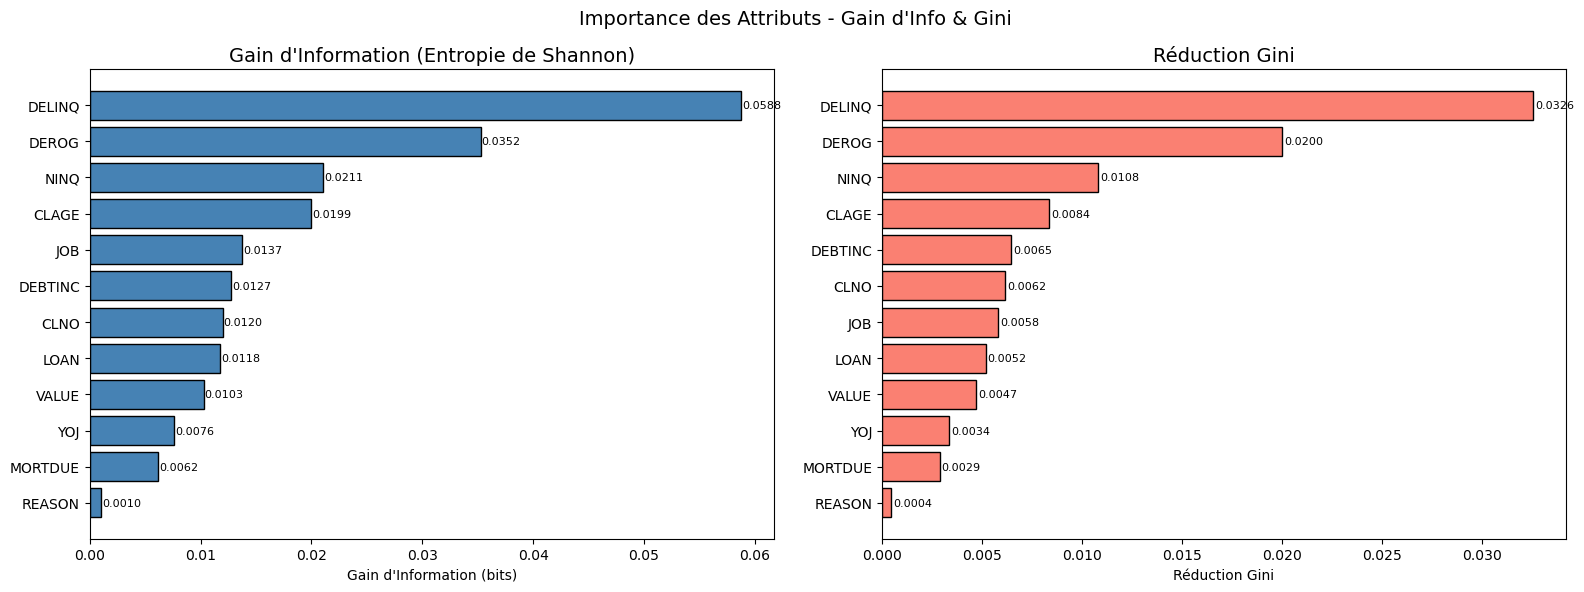

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# gain d'information
axes[0].barh(results['Attribut'], results['Gain Info (Entropie)'], color='steelblue', edgecolor='black')
axes[0].set_title('Gain d\'Information (Entropie de Shannon)', fontsize=14)
axes[0].set_xlabel('Gain d\'Information (bits)')
axes[0].invert_yaxis()
for i, (v,n) in enumerate(zip(results['Gain Info (Entropie)'], results['Attribut'])):
    axes[0].text(v + 0.0001, i, f'{v:.4f}', va='center', fontsize=8)
    
results_gini = results.sort_values('Réduction Gini', ascending=False)
axes[1].barh(results_gini['Attribut'], results_gini['Réduction Gini'], color='salmon', edgecolor='black')
axes[1].set_title('Réduction Gini', fontsize=14)
axes[1].set_xlabel('Réduction Gini')
axes[1].invert_yaxis()
for i, v in enumerate(results_gini['Réduction Gini']):
    axes[1].text(v + 0.0001, i, f'{v:.4f}', va='center', fontsize=8)

plt.suptitle("Importance des Attributs - Gain d'Info & Gini", fontsize=14)
plt.tight_layout()
plt.savefig('figs/q3_feature_importance.png', dpi=150)
plt.show()

Problèmes dans le dataset (suite+traitement)

In [100]:
data_clean = data.copy()
data_clean.isnull().sum()
print(data_clean.isnull().sum())

BAD           0
LOAN          0
MORTDUE     518
VALUE       112
REASON      252
JOB         279
YOJ         515
DEROG       708
DELINQ      580
CLAGE       308
NINQ        510
CLNO        222
DEBTINC    1267
dtype: int64


Variables numériques: imputation par la médiane

In [101]:
numeric_features = ['MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC']
for col in numeric_features:
    median = data_clean[col].median()
    data_clean[col].fillna(median, inplace=True)

Variables catégorielles: imputation par le mode (valeur la plus fréquente)

In [102]:
for col in ['REASON', 'JOB']:
    mode_val = data_clean[col].mode()[0]
    data_clean[col].fillna(mode_val, inplace=True)

Après nettoyage

In [103]:
print(data_clean.isnull().sum())

BAD        0
LOAN       0
MORTDUE    0
VALUE      0
REASON     0
JOB        0
YOJ        0
DEROG      0
DELINQ     0
CLAGE      0
NINQ       0
CLNO       0
DEBTINC    0
dtype: int64


Encodage des variables catégorielles

In [104]:
le_reason = LabelEncoder()
le_job = LabelEncoder()
data_clean['REASON_ENC'] = le_reason.fit_transform(data_clean['REASON'])
data_clean['JOB_ENC'] = le_job.fit_transform(data_clean['JOB'])
data_clean.drop(['REASON', 'JOB'], axis=1, inplace=True)
data_clean.head()

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,REASON_ENC,JOB_ENC
0,1,1100,25860.0,39025.0,10.5,0.0,0.0,94.366667,1.0,9.0,34.818262,1,2
1,1,1300,70053.0,68400.0,7.0,0.0,2.0,121.833333,0.0,14.0,34.818262,1,2
2,1,1500,13500.0,16700.0,4.0,0.0,0.0,149.466667,1.0,10.0,34.818262,1,2
3,1,1500,65019.0,89235.5,7.0,0.0,0.0,173.466667,1.0,20.0,34.818262,0,2
4,0,1700,97800.0,112000.0,3.0,0.0,0.0,93.333333,0.0,14.0,34.818262,1,1


Résumé du déséquilibre de classes

In [105]:
vc = data_clean['BAD'].value_counts()
print(f"  BAD=0 : {vc[0]} ({vc[0]/len(data_clean)*100:.1f}%) — Bon payeur")
print(f"  BAD=1 : {vc[1]} ({vc[1]/len(data_clean)*100:.1f}%) — Défaut")

  BAD=0 : 4771 (80.1%) — Bon payeur
  BAD=1 : 1189 (19.9%) — Défaut


Ce déséquilibre sera géré via `class_weight='balanced'` dans le modèle

Vérification finale:

Dataset final

In [106]:
data_clean.shape

(5960, 13)

In [107]:
data_clean.head()

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,REASON_ENC,JOB_ENC
0,1,1100,25860.0,39025.0,10.5,0.0,0.0,94.366667,1.0,9.0,34.818262,1,2
1,1,1300,70053.0,68400.0,7.0,0.0,2.0,121.833333,0.0,14.0,34.818262,1,2
2,1,1500,13500.0,16700.0,4.0,0.0,0.0,149.466667,1.0,10.0,34.818262,1,2
3,1,1500,65019.0,89235.5,7.0,0.0,0.0,173.466667,1.0,20.0,34.818262,0,2
4,0,1700,97800.0,112000.0,3.0,0.0,0.0,93.333333,0.0,14.0,34.818262,1,1


In [108]:
list(data_clean.columns)

['BAD',
 'LOAN',
 'MORTDUE',
 'VALUE',
 'YOJ',
 'DEROG',
 'DELINQ',
 'CLAGE',
 'NINQ',
 'CLNO',
 'DEBTINC',
 'REASON_ENC',
 'JOB_ENC']

Matrice de corrélation

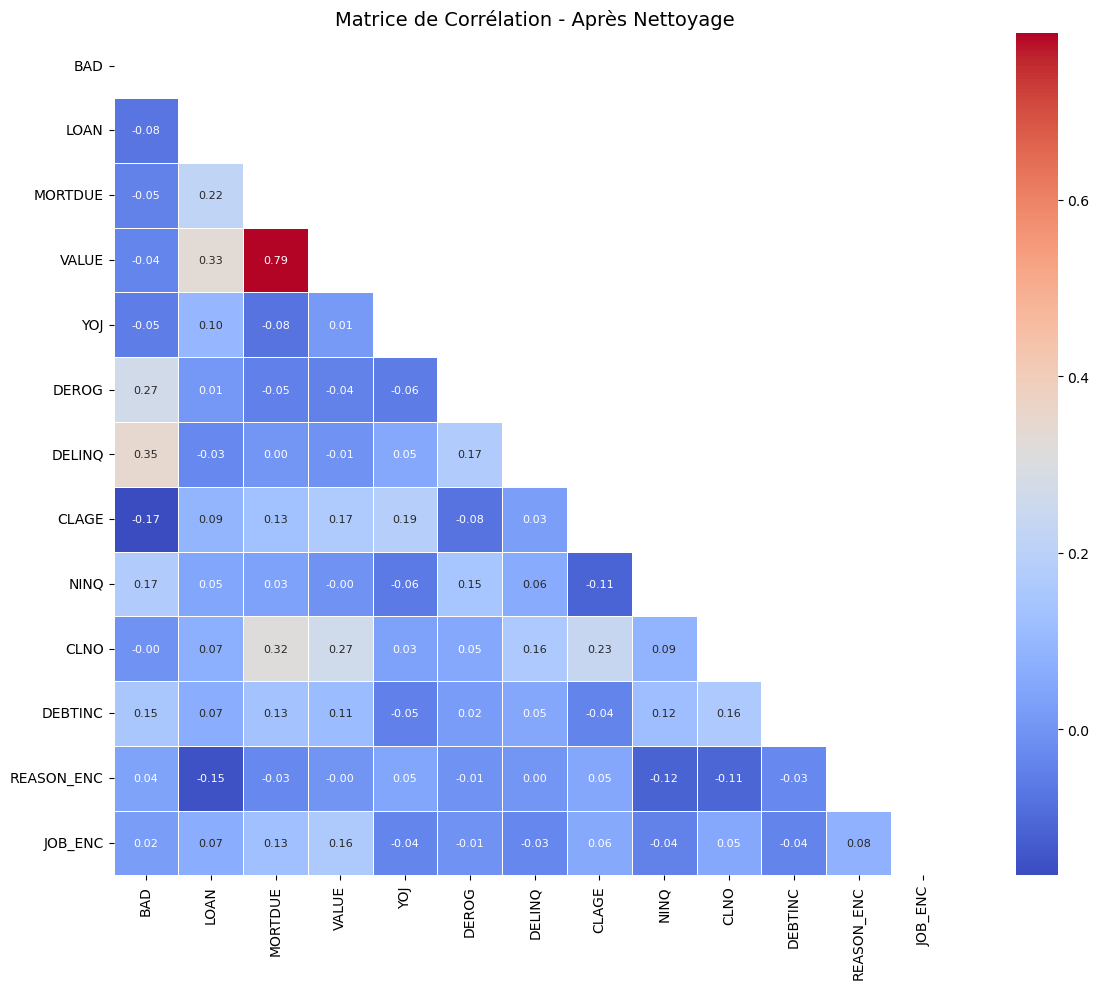

In [109]:
plt.figure(figsize=(13, 10))
corr_matrix = data_clean.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', mask=mask, square=True,
            linewidths=0.5, annot_kws={"size": 8})
plt.title('Matrice de Corrélation - Après Nettoyage', fontsize=14)
plt.tight_layout()
plt.savefig('figs/q4_correlation_matrix.png', dpi=150)
plt.show()

5. Modèle de prédiction (Arbre de décision, test_size=0.33)

Préparation des données

In [110]:
X = data_clean.drop('BAD', axis=1)
y = data_clean['BAD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

Modèle de base

In [111]:
dt_base = DecisionTreeClassifier(criterion='gini', random_state=42, class_weight='balanced')
dt_base.fit(X_train, y_train)
y_pred_base = dt_base.predict(X_test)
y_proba_base = dt_base.predict_proba(X_test)[:, 1]

In [112]:
print(f"Profondeur de l'arbre : {dt_base.get_depth()}")
print(f"Nombre de feuilles : {dt_base.get_n_leaves()}")
print(f"Nombre de nœuds : {dt_base.tree_.node_count}")

Profondeur de l'arbre : 22
Nombre de feuilles : 428
Nombre de nœuds : 855


In [113]:
print("Métriques:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_base)*100:.2f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_base):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_base, target_names=["Bon payeur (0)", "Défaut (1)"]))

Métriques:
Accuracy: 87.14
AUC-ROC: 0.7788

Classification Report:
                precision    recall  f1-score   support

Bon payeur (0)       0.91      0.93      0.92      1575
    Défaut (1)       0.70      0.62      0.66       392

      accuracy                           0.87      1967
     macro avg       0.80      0.78      0.79      1967
  weighted avg       0.87      0.87      0.87      1967



Matrice de confusion

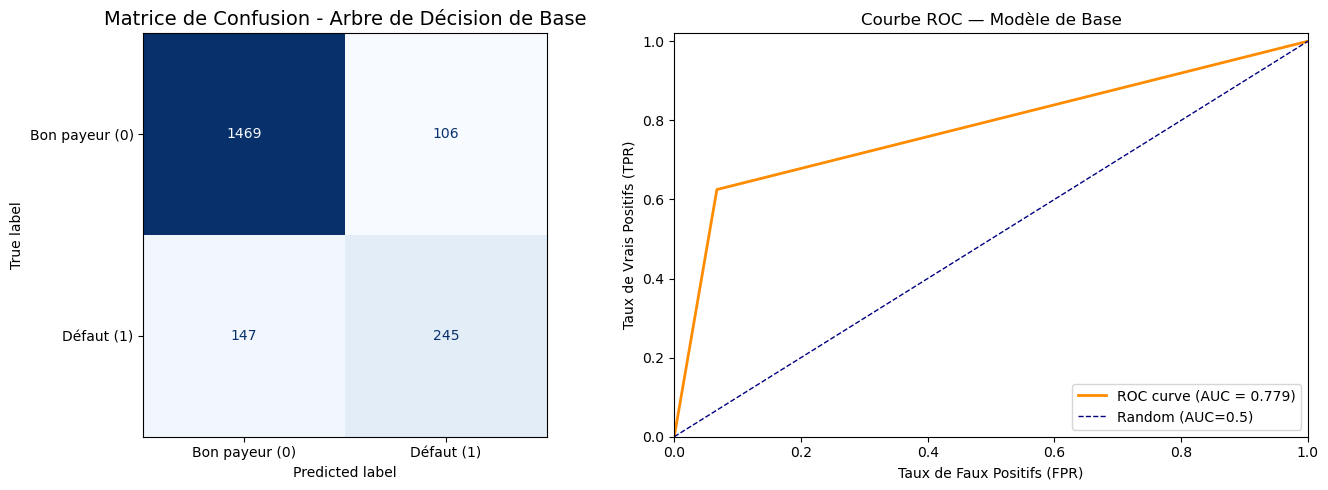

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_base = confusion_matrix(y_test, y_pred_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_base,
                              display_labels=["Bon payeur (0)", "Défaut (1)"])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matrice de Confusion - Arbre de Décision de Base', fontsize=14)
fpr, tpr, _ = roc_curve(y_test, y_proba_base)
auc_base = roc_auc_score(y_test, y_proba_base)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_base:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random (AUC=0.5)')
axes[1].set_xlabel('Taux de Faux Positifs (FPR)')
axes[1].set_ylabel('Taux de Vrais Positifs (TPR)')
axes[1].set_title('Courbe ROC — Modèle de Base')
axes[1].legend(loc='lower right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('figs/q5_base_model_evaluation.png', dpi=150)
plt.show()

Visualisation de l'arbre (profondeur limitée pour meilleure lisibilité)

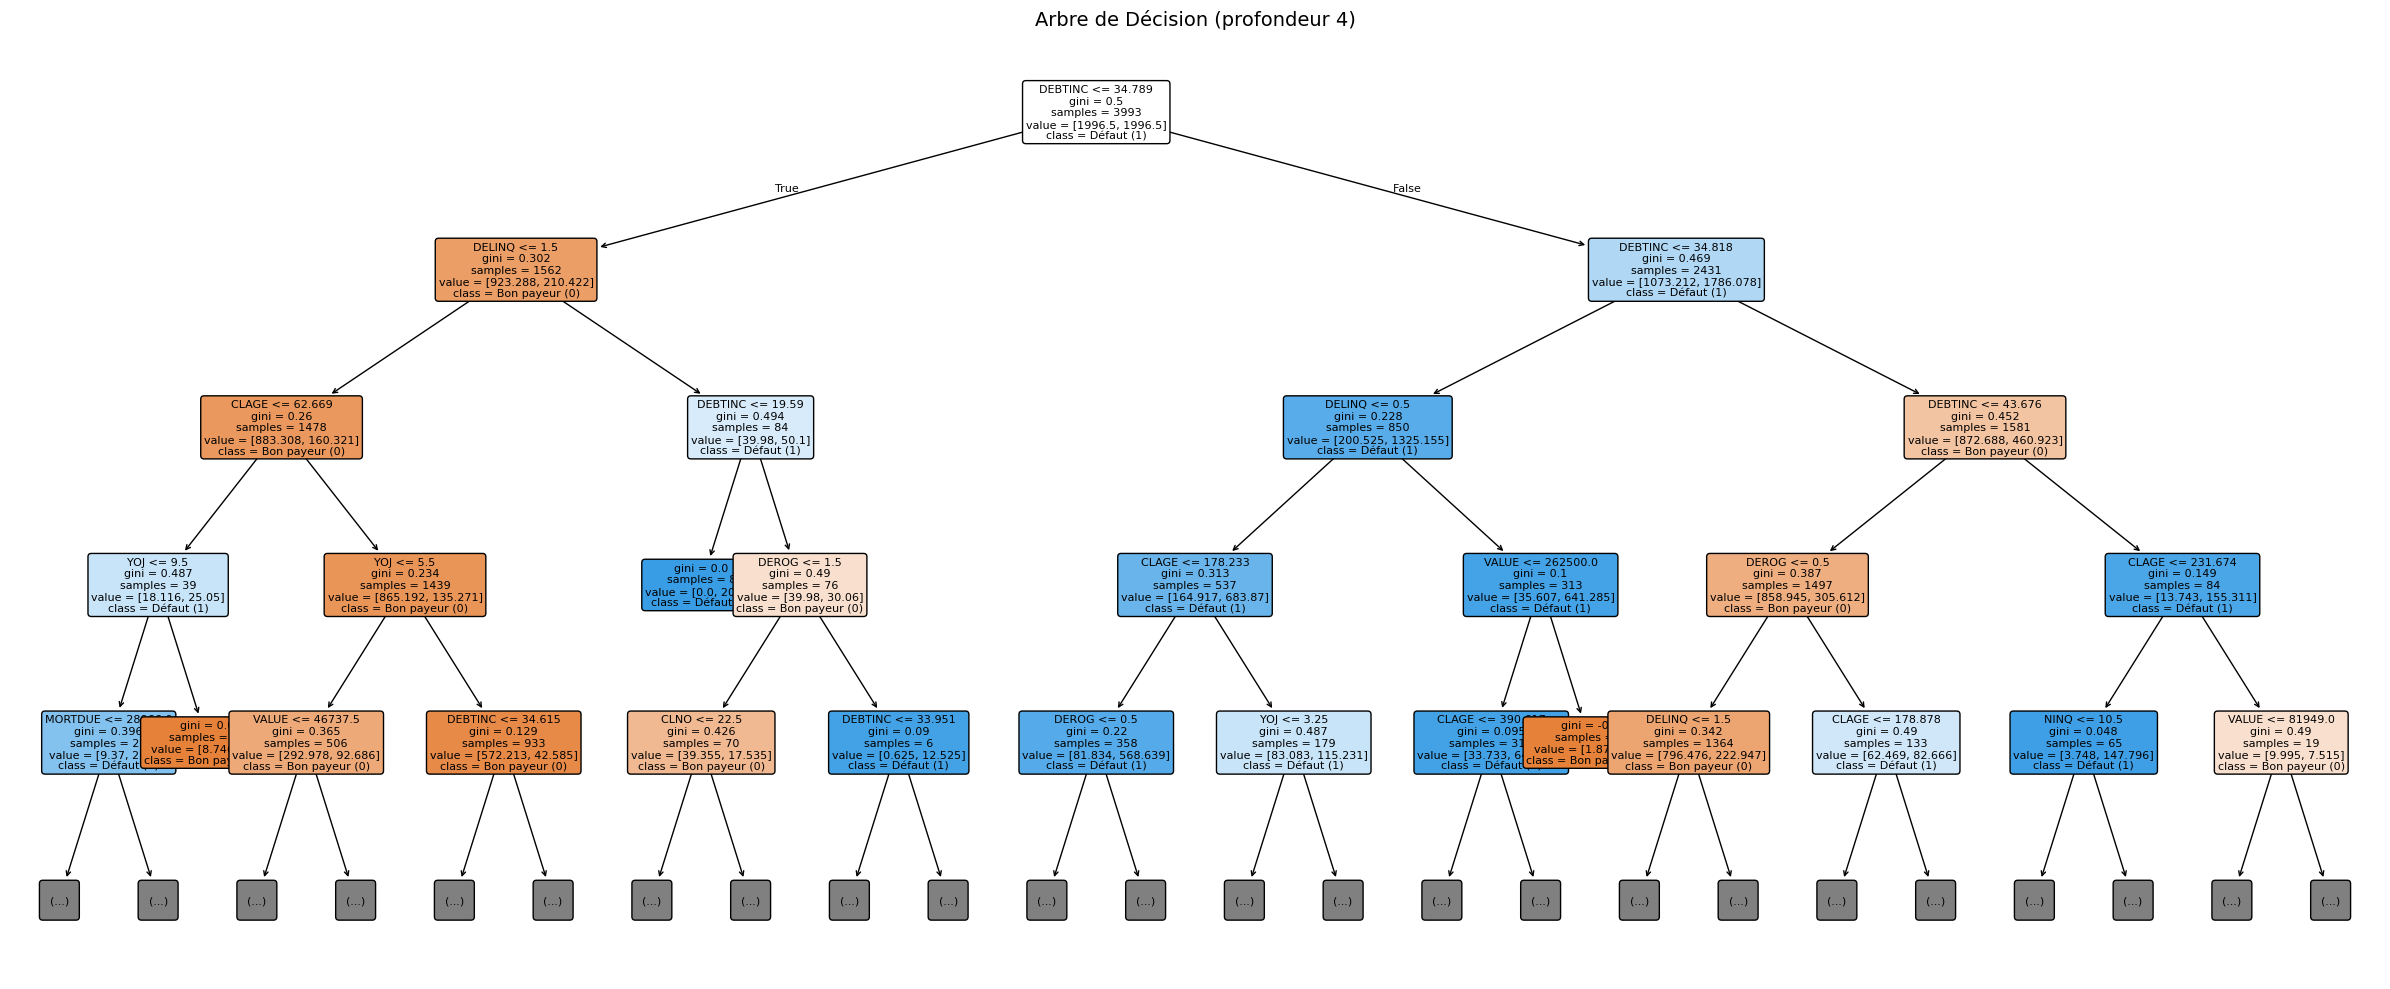

In [115]:
plt.figure(figsize=(24, 10))
plot_tree(dt_base, max_depth=4, feature_names=X.columns.tolist(),
          class_names=["Bon payeur (0)", "Défaut (1)"], filled=True, rounded=True,
          fontsize=8, impurity=True, proportion=False)
plt.title("Arbre de Décision (profondeur 4)", fontsize=14)
plt.tight_layout()
plt.savefig('figs/q5_decision_tree.png', dpi=150)
plt.show()

Règles textuelles de l'arbre (top 30 lignes)

In [116]:
rules = export_text(dt_base, feature_names=list(X.columns), max_depth=4)
print(rules[:2000])

|--- DEBTINC <= 34.79
|   |--- DELINQ <= 1.50
|   |   |--- CLAGE <= 62.67
|   |   |   |--- YOJ <= 9.50
|   |   |   |   |--- MORTDUE <= 28966.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- MORTDUE >  28966.00
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- YOJ >  9.50
|   |   |   |   |--- class: 0
|   |   |--- CLAGE >  62.67
|   |   |   |--- YOJ <= 5.50
|   |   |   |   |--- VALUE <= 46737.50
|   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |   |--- VALUE >  46737.50
|   |   |   |   |   |--- truncated branch of depth 10
|   |   |   |--- YOJ >  5.50
|   |   |   |   |--- DEBTINC <= 34.62
|   |   |   |   |   |--- truncated branch of depth 14
|   |   |   |   |--- DEBTINC >  34.62
|   |   |   |   |   |--- truncated branch of depth 3
|   |--- DELINQ >  1.50
|   |   |--- DEBTINC <= 19.59
|   |   |   |--- class: 1
|   |   |--- DEBTINC >  19.59
|   |   |   |--- DEROG <= 1.50
|   |   |   |   |--- CLNO <= 22.50
|   |   |   |   |   |--- truncated bran

6. Optimisation du modèle

GridSearchCV sur hyperparamètres clés

In [117]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3,4,5,6,7,8,10,None],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_features': [None, 'sqrt', 'log2'],
    'class_weight': ['balanced', None]
}
dt_grid = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(
    dt_grid, param_grid,
    cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)
print(f"Meilleurs hyperparamètres : {grid_search.best_params_}")
print(f"Meilleur score AUC-ROC (CV) : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 1536 candidates, totalling 7680 fits
Meilleurs hyperparamètres : {'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 50}
Meilleur score AUC-ROC (CV) : 0.8867


Modèle optimisé

In [118]:
best_dt = grid_search.best_estimator_
y_pred_opt = best_dt.predict(X_test)
y_proba_opt = best_dt.predict_proba(X_test)[:, 1]

Comparaison Base vs Optimisé

In [119]:
acc_base = accuracy_score(y_test, y_pred_base)
acc_opt = accuracy_score(y_test, y_pred_opt)
auc_opt = roc_auc_score(y_test, y_proba_opt)
print(f"{'Accuracy':<25} {acc_base*100:>14.2f}% {acc_opt*100:>17.2f}%")
print(f"{'AUC-ROC':<25} {auc_base:>15.4f} {auc_opt:>18.4f}")
print(f"{'Profondeur arbre':<25} {dt_base.get_depth():>15} {best_dt.get_depth():>18}")
print(f"{'Nombre de feuilles':<25} {dt_base.get_n_leaves():>15} {best_dt.get_n_leaves():>18}")

Accuracy                           87.14%             87.54%
AUC-ROC                            0.7788             0.8792
Profondeur arbre                       22                 10
Nombre de feuilles                    428                 70


Rapport complet (modèle optimisé):

In [120]:
print(classification_report(y_test, y_pred_opt, target_names=["Bon payeur (0)", "Défaut (1)"]))

                precision    recall  f1-score   support

Bon payeur (0)       0.90      0.96      0.92      1575
    Défaut (1)       0.76      0.55      0.64       392

      accuracy                           0.88      1967
     macro avg       0.83      0.75      0.78      1967
  weighted avg       0.87      0.88      0.87      1967



Validation croiséée 10-fold

In [121]:
cv_scores_acc = cross_val_score(best_dt, X, y, cv=10, scoring='accuracy')
cv_scores_auc = cross_val_score(best_dt, X, y, cv=10, scoring='roc_auc')
print(f"  Accuracy  : {cv_scores_acc.mean()*100:.2f}% ± {cv_scores_acc.std()*100:.2f}%")
print(f"  AUC-ROC   : {cv_scores_auc.mean():.4f} ± {cv_scores_auc.std():.4f}")

  Accuracy  : 80.07% ± 19.11%
  AUC-ROC   : 0.8259 ± 0.1077


Importance des features (modèle optimisé)

In [122]:
feat_imp = pd.DataFrame({
    'Feature' : X.columns,
    'Importance': best_dt.feature_importances_
}).sort_values('Importance', ascending=False)

Visualisations finales

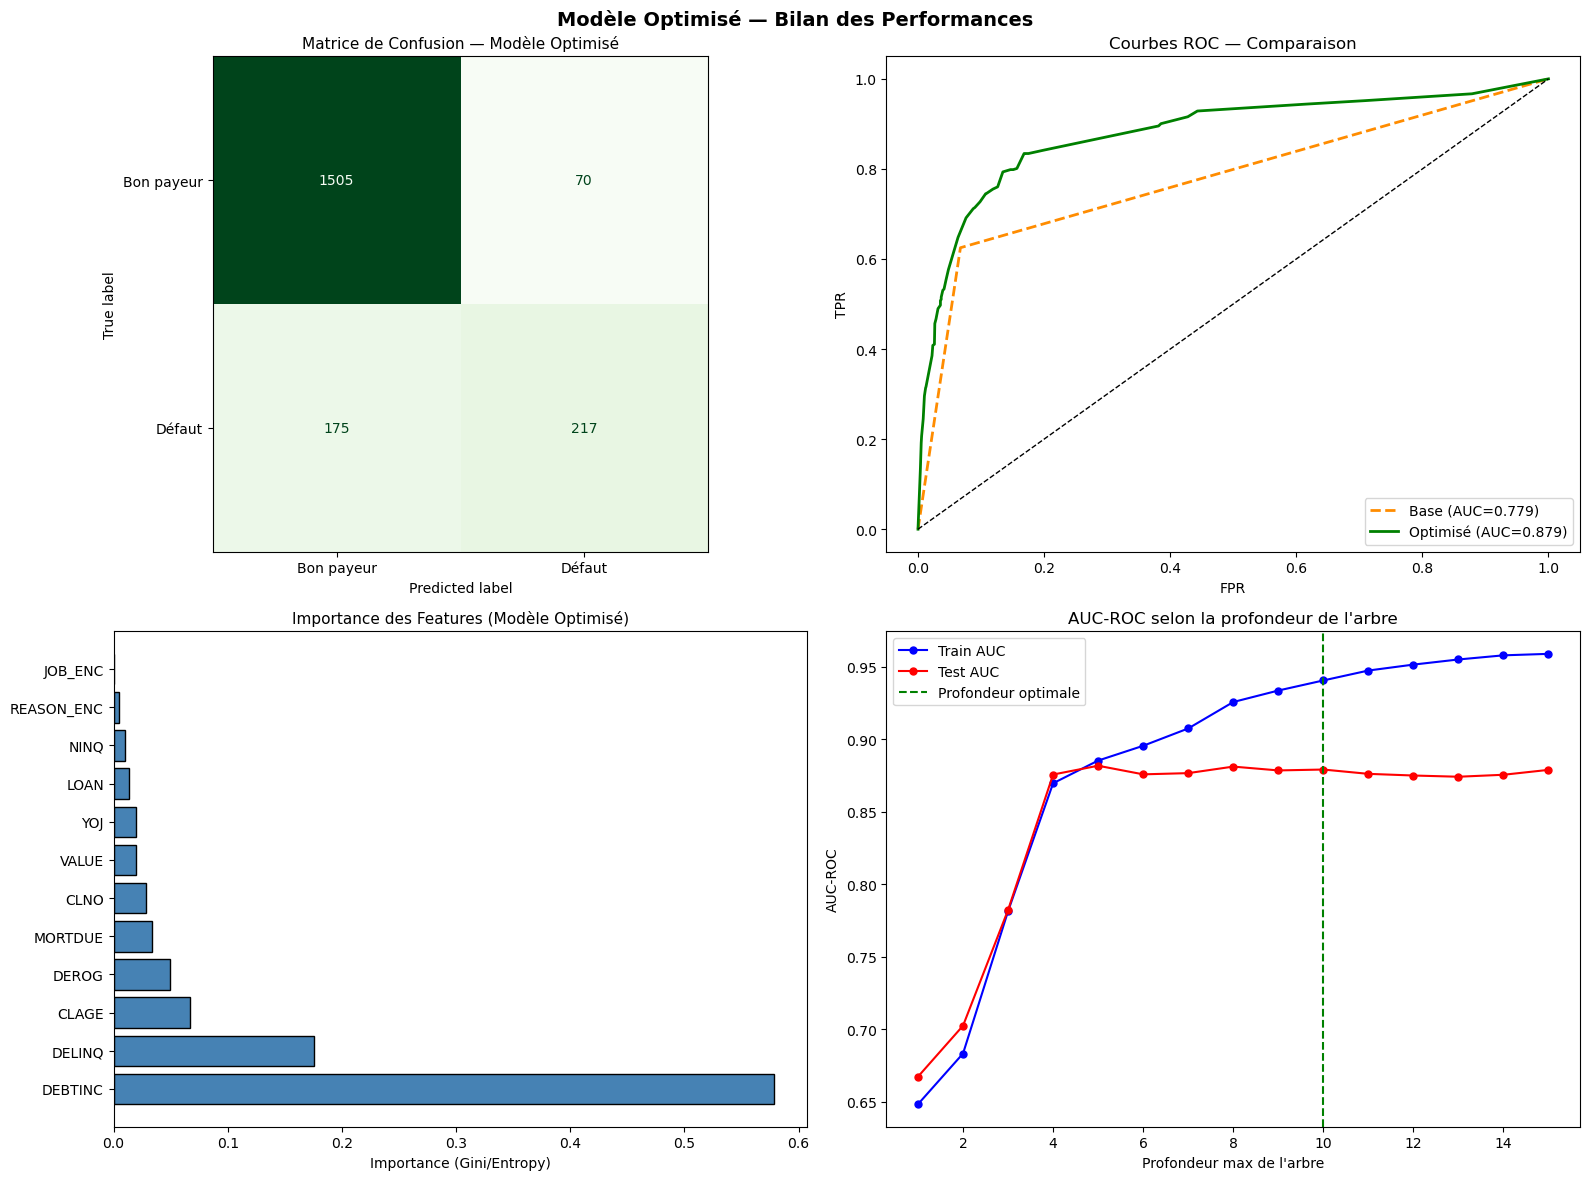

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

cm_opt = confusion_matrix(y_test, y_pred_opt)
ConfusionMatrixDisplay(confusion_matrix=cm_opt,
                       display_labels=['Bon payeur', 'Défaut']).plot(
    ax=axes[0, 0], colorbar=False, cmap='Greens')
axes[0, 0].set_title('Matrice de Confusion — Modèle Optimisé', fontsize=11)

fpr_opt, tpr_opt, _ = roc_curve(y_test, y_proba_opt)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, linestyle='--',
                label=f'Base (AUC={auc_base:.3f})')
axes[0, 1].plot(fpr_opt, tpr_opt, color='green', lw=2,
                label=f'Optimisé (AUC={auc_opt:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 1].set_xlabel('FPR')
axes[0, 1].set_ylabel('TPR')
axes[0, 1].set_title('Courbes ROC — Comparaison')
axes[0, 1].legend(loc='lower right')

axes[1, 0].barh(feat_imp['Feature'], feat_imp['Importance'],
                color='steelblue', edgecolor='black')
axes[1, 0].set_title("Importance des Features (Modèle Optimisé)", fontsize=11)
axes[1, 0].set_xlabel('Importance (Gini/Entropy)')

depths = list(range(1, 16))
train_aucs, test_aucs = [], []
for d in depths:
    tmp = DecisionTreeClassifier(
        criterion=grid_search.best_params_['criterion'],
        max_depth=d,
        min_samples_split=grid_search.best_params_['min_samples_split'],
        min_samples_leaf=grid_search.best_params_['min_samples_leaf'],
        class_weight=grid_search.best_params_['class_weight'],
        random_state=42
    )
    tmp.fit(X_train, y_train)
    train_aucs.append(roc_auc_score(y_train, tmp.predict_proba(X_train)[:, 1]))
    test_aucs.append(roc_auc_score(y_test, tmp.predict_proba(X_test)[:, 1]))
axes[1, 1].plot(depths, train_aucs, 'b-o', label='Train AUC', markersize=5)
axes[1, 1].plot(depths, test_aucs, 'r-o', label='Test AUC', markersize=5)
best_depth_shown = grid_search.best_params_.get('max_depth', 'None')
axes[1, 1].axvline(x=best_depth_shown if isinstance(best_depth_shown, int) else max(depths),
                   color='green', linestyle='--', label=f'Profondeur optimale')
axes[1, 1].set_xlabel('Profondeur max de l\'arbre')
axes[1, 1].set_ylabel('AUC-ROC')
axes[1, 1].set_title('AUC-ROC selon la profondeur de l\'arbre')
axes[1, 1].legend()

plt.suptitle('Modèle Optimisé — Bilan des Performances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figs/q6_optimized_model.png', dpi=150)
plt.show()

Visualisation de l'arbre optimisé

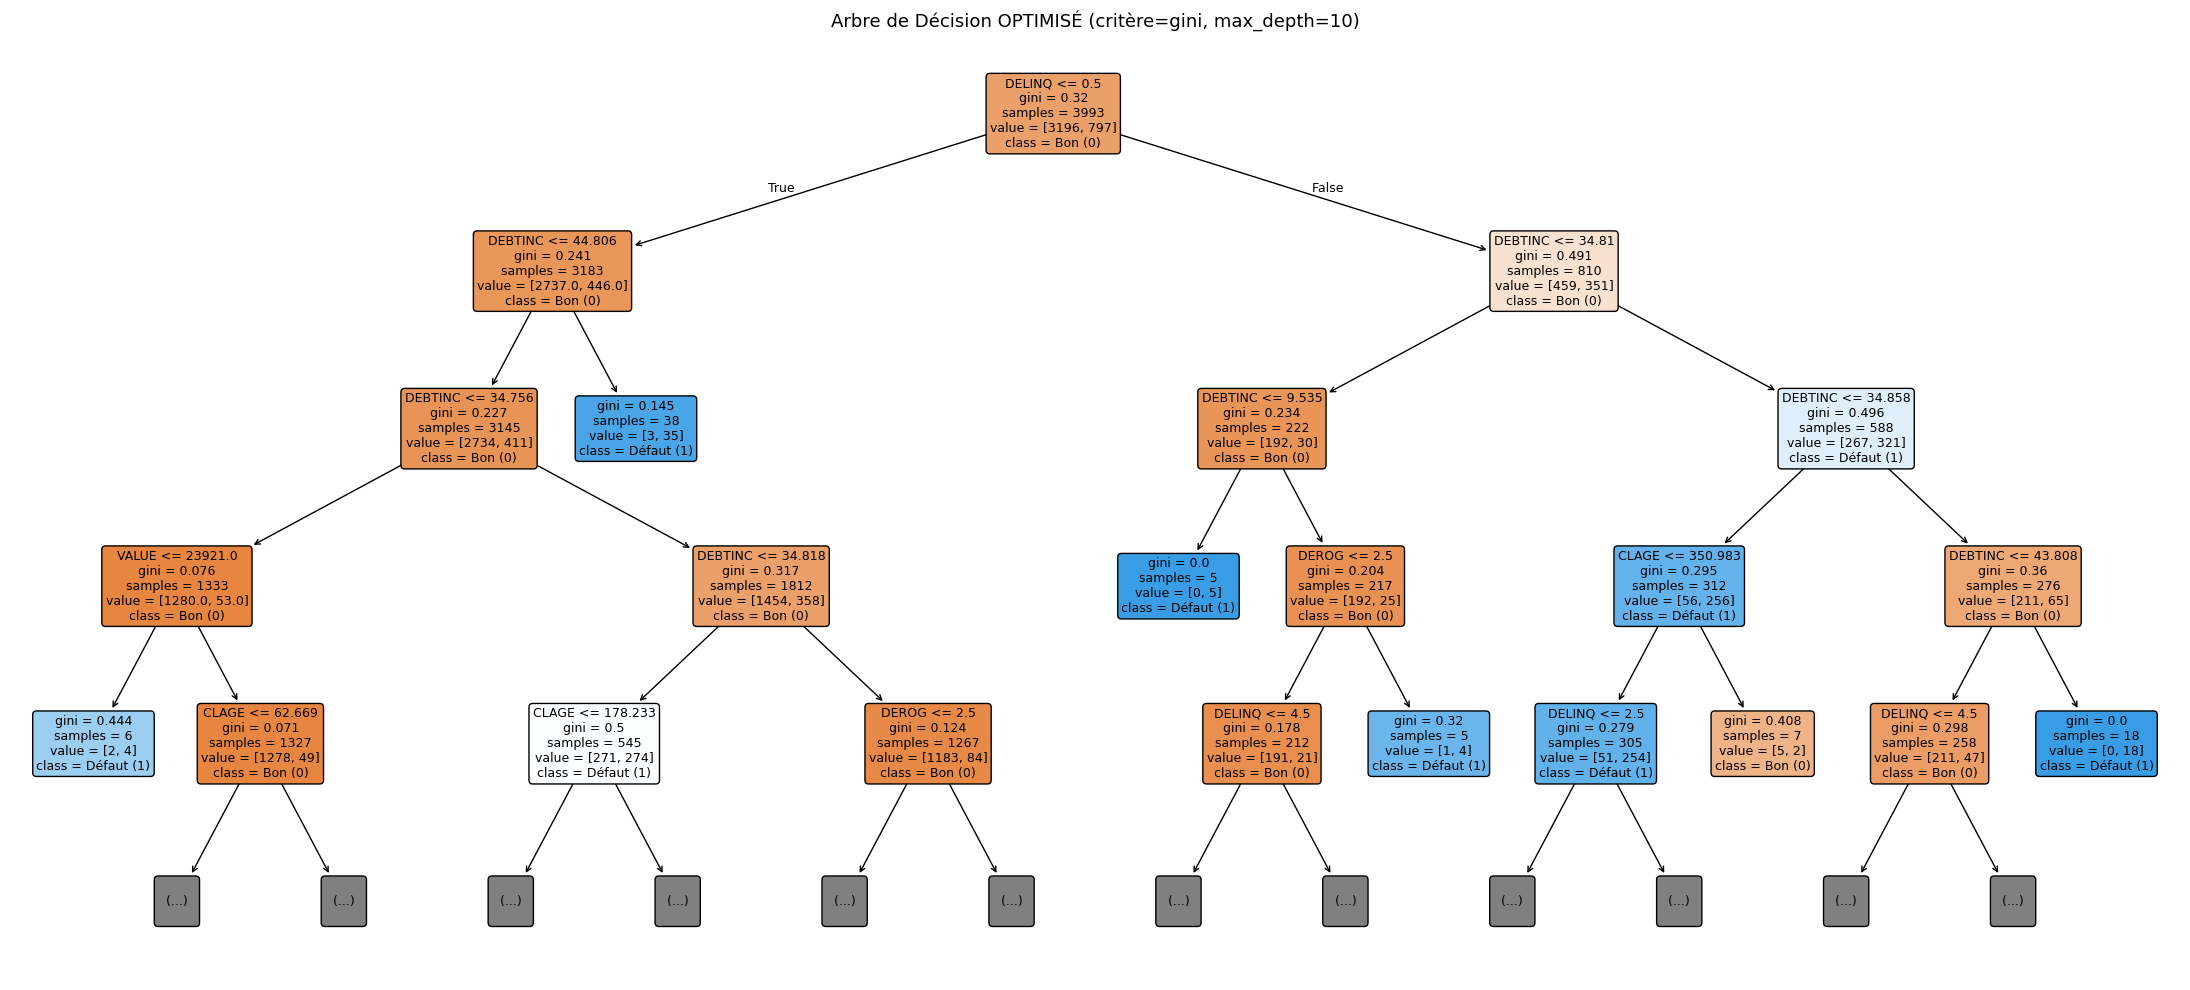

In [ ]:
plt.figure(figsize=(22, 10))
plot_tree(best_dt, max_depth=4, feature_names=X.columns.tolist(),
          class_names=['Bon (0)', 'Défaut (1)'], filled=True, rounded=True,
          fontsize=9, impurity=True)
plt.title(f"Arbre de Décision OPTIMISÉ (critère={grid_search.best_params_['criterion']}, "
          f"max_depth={grid_search.best_params_['max_depth']})", fontsize=13)
plt.tight_layout()
plt.savefig('figs/q6_optimized_tree.png', dpi=150, bbox_inches='tight')
plt.show()